# 09. RNN con preprocesados y vectorizaciones

En este notebook se prueba una **red recurrente simple (SimpleRNN)** sobre los distintos datasets preprocesados.

La idea es comparar:

```text
preprocesado + vectorización + RNN
```

En las vectorizaciones clásicas (`Binaria`, `Frecuencia`, `Tfidf`) se utiliza el vocabulario generado por el vectorizador para convertir el texto en una secuencia de índices.  
En las vectorizaciones con embeddings (`Word2Vec`, `FastText`) se usa una representación secuencial, es decir, **un vector por palabra**, sin hacer pooling. Esto equivale a usar `vectorizacionEmbeddings(..., metodo=2)`.

In [48]:
import pandas as pd
import numpy as np
import sys
import os
import gc
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../Code"))
import vectorize

In [49]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU disponible: []


## Configuración

Los `DATA_PATHS` apuntan a los datasets originales y preprocesados. Si alguno no existe, se salta automáticamente.

Para que el notebook no sea excesivamente lento, `MAX_LEN` se deja en 200. Si se quiere probar con textos más largos se puede subir a 300 o 400, aunque con embeddings puede consumir bastante memoria.

In [50]:
DATA_PATHS = [
    '../Data/raw/tcga_simple_train.csv',
    '../Data/interim/tcga_simple_train_preprocessed_0.csv',
    '../Data/interim/tcga_simple_train_preprocessed_1.csv',
    '../Data/interim/tcga_simple_train_preprocessed_2.csv',
    '../Data/interim/tcga_simple_train_preprocessed_3.csv',
    '../Data/interim/tcga_simple_train_preprocessed_4.csv',
    '../Data/interim/tcga_simple_train_preprocessed_3_augmented.csv',
]

RESULTS_PATH = '../Results/Metrics/rnn.csv'
BEST_MODEL_PATH = '../Models/best_rnn.keras'

os.makedirs('../Results/Metrics', exist_ok=True)
os.makedirs('../Models', exist_ok=True)

MAX_LEN = 200
BATCH_SIZE = 32
EPOCHS = 20

# Si tarda demasiado, deja solo una o dos vectorizaciones.
vectorizadores = ["Binaria", "Frecuencia", "Tfidf", "Word2Vec", "FastText"]

print("Vectorizaciones a probar:", vectorizadores)

Vectorizaciones a probar: ['Binaria', 'Frecuencia', 'Tfidf', 'Word2Vec', 'FastText']


## Carga de embeddings

In [51]:
w2v_model = None
fasttext_model = None

if "Word2Vec" in vectorizadores:
    import gensim.downloader
    print("Cargando Word2Vec...")
    w2v_model = gensim.downloader.load('word2vec-google-news-300')
    print("Word2Vec cargado")

if "FastText" in vectorizadores:
    from gensim.models.fasttext import load_facebook_model
    fasttext_path = "../Models/wiki.simple.bin"

    if os.path.exists(fasttext_path):
        print("Cargando FastText...")
        fasttext_model = load_facebook_model(fasttext_path)
        print("FastText cargado")
    else:
        print("No se ha encontrado FastText en:", fasttext_path)
        print("Se elimina FastText de la lista de vectorizaciones")
        vectorizadores = [v for v in vectorizadores if v != "FastText"]

Cargando Word2Vec...
Word2Vec cargado
No se ha encontrado FastText en: ../Models/wiki.simple.bin
Se elimina FastText de la lista de vectorizaciones


## Funciones auxiliares

Para las vectorizaciones clásicas, se obtiene un vocabulario y se transforma cada informe en una secuencia de índices.

Para Word2Vec/FastText, se convierte cada informe en una matriz:

```text
nº tokens x dimensión del embedding
```

Después se aplica padding hasta `MAX_LEN`, quedando:

```text
nº documentos x MAX_LEN x dimensión del embedding
```

In [52]:
def texto_a_secuencia(serie_texto, mapping, max_len):
    """
    Convierte cada texto en una secuencia de índices a partir de un vocabulario.
    Esta parte se usa con Binaria, Frecuencia y TF-IDF.
    """
    secuencias = []

    for texto in serie_texto.astype(str):
        seq = [mapping[w] for w in texto.split() if w in mapping]
        secuencias.append(seq)

    return pad_sequences(secuencias, maxlen=max_len, padding="post", truncating="post")


def obtener_keyed_vectors(modelo):
    """
    Devuelve el objeto que realmente contiene los vectores.
    Sirve tanto para modelos tipo Word2Vec/FastText como para KeyedVectors.
    """
    if hasattr(modelo, "wv"):
        return modelo.wv
    return modelo


def dimension_embeddings(modelo):
    keyed = obtener_keyed_vectors(modelo)

    if hasattr(keyed, "vector_size"):
        return keyed.vector_size

    primera_palabra = list(keyed.key_to_index.keys())[0]
    return len(keyed[primera_palabra])


def vectorizacion_embeddings_rnn(textos, modelo, max_len):
    """
    Vectorización de embeddings para RNN.

    Es la versión secuencial de vectorizacionEmbeddings con metodo=2:
    no hace media ni suma, sino que mantiene un vector por palabra.

    Devuelve:
    - X: array de forma (n_textos, max_len, embedding_dim)
    """
    keyed = obtener_keyed_vectors(modelo)
    emb_dim = dimension_embeddings(modelo)

    X = np.zeros((len(textos), max_len, emb_dim), dtype=np.float32)

    for i, texto in enumerate(textos.astype(str)):
        palabras = [w for w in texto.split() if w in keyed]

        if len(palabras) == 0:
            continue

        palabras = palabras[:max_len]
        vectores = keyed[palabras]

        X[i, :len(palabras), :] = vectores

    return X

In [53]:
def build_rnn_model(input_type, vocab_size=None, input_dim=None):
    """
    Construye un modelo SimpleRNN.

    input_type = 'secuencia_ids':
        Entrada como índices de palabras. Se usa capa Embedding entrenable.

    input_type = 'secuencia_embeddings':
        Entrada como secuencia de vectores Word2Vec/FastText. No se usa capa Embedding.
    """
    model = Sequential()

    if input_type == 'secuencia_ids':
        model.add(Embedding(
            input_dim=vocab_size + 1,
            output_dim=32,
            input_length=MAX_LEN,
            mask_zero=True
        ))

    elif input_type == 'secuencia_embeddings':
        model.add(Masking(
            mask_value=0.0,
            input_shape=(MAX_LEN, input_dim)
        ))

    else:
        raise ValueError("input_type no reconocido")

    model.add(SimpleRNN(
        units=16,
        activation='tanh',
        dropout=0.4,
        recurrent_dropout=0.0
    ))

    model.add(Dense(4, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Entrenamiento de los experimentos

In [54]:
resultados = []

best_f1 = -1
best_info = None
best_y_true = None
best_y_pred = None
best_labels = None

for data_path in DATA_PATHS:

    if not os.path.exists(data_path):
        print(f"No existe el dataset, se salta: {data_path}")
        continue

    dataset_name = os.path.basename(data_path)
    print("=" * 80)
    print(f"PROCESANDO DATASET: {dataset_name}")
    print("=" * 80)

    df = pd.read_csv(data_path)
    df = df.dropna(subset=["text", "t"]).copy()
    df["text"] = df["text"].astype(str)
    df["t"] = df["t"].astype(str).str.upper().str.strip()

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        df["text"],
        df["t"],
        test_size=0.2,
        random_state=23,
        stratify=df["t"]
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        random_state=33,
        stratify=y_train_full
    )

    le = LabelEncoder()
    y_train_num = le.fit_transform(y_train)
    y_val_num = le.transform(y_val)
    y_test_num = le.transform(y_test)

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_num),
        y=y_train_num
    )
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}

    for nombre_vec in vectorizadores:
        print(f"\n -> Evaluando RNN con vectorización: {nombre_vec}")

        try:
            if nombre_vec in ["Binaria", "Frecuencia", "Tfidf"]:

                if nombre_vec == "Binaria":
                    _, v = vectorize.vectorizacionBinaria(X_train)
                elif nombre_vec == "Frecuencia":
                    _, v = vectorize.vectorizacionFreq(X_train)
                else:
                    _, v = vectorize.vectorizacionTfidf(X_train)

                vocab_map = v.vocabulary_
                index_mapping = {word: (idx + 1) for word, idx in vocab_map.items()}

                X_train_nn = texto_a_secuencia(X_train, index_mapping, MAX_LEN)
                X_val_nn = texto_a_secuencia(X_val, index_mapping, MAX_LEN)
                X_test_nn = texto_a_secuencia(X_test, index_mapping, MAX_LEN)

                num_words = len(v.get_feature_names_out()) + 1
                model = build_rnn_model('secuencia_ids', vocab_size=num_words)

            elif nombre_vec == "Word2Vec":
                X_train_nn = vectorizacion_embeddings_rnn(X_train, w2v_model, MAX_LEN)
                X_val_nn = vectorizacion_embeddings_rnn(X_val, w2v_model, MAX_LEN)
                X_test_nn = vectorizacion_embeddings_rnn(X_test, w2v_model, MAX_LEN)

                input_dim = X_train_nn.shape[2]
                model = build_rnn_model('secuencia_embeddings', input_dim=input_dim)

            elif nombre_vec == "FastText":
                X_train_nn = vectorizacion_embeddings_rnn(X_train, fasttext_model, MAX_LEN)
                X_val_nn = vectorizacion_embeddings_rnn(X_val, fasttext_model, MAX_LEN)
                X_test_nn = vectorizacion_embeddings_rnn(X_test, fasttext_model, MAX_LEN)

                input_dim = X_train_nn.shape[2]
                model = build_rnn_model('secuencia_embeddings', input_dim=input_dim)

            else:
                print("Vectorización no reconocida:", nombre_vec)
                continue

            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True
            )

            history = model.fit(
                X_train_nn,
                y_train_num,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                validation_data=(X_val_nn, y_val_num),
                callbacks=[early_stop],
                class_weight=class_weight_dict,
                verbose=0
            )

            predicciones_prob = model.predict(X_test_nn, verbose=0)
            clases_predichas = np.argmax(predicciones_prob, axis=1)

            macro_f1 = f1_score(y_test_num, clases_predichas, average='macro')

            resultados.append({
                "Dataset": dataset_name,
                "Vectorizacion": nombre_vec,
                "Modelo": "SimpleRNN",
                "Max_len": MAX_LEN,
                "Macro_F1": round(macro_f1, 4)
            })

            print(f"Macro F1: {macro_f1:.4f}")

            if macro_f1 > best_f1:
                best_f1 = macro_f1
                best_info = {
                    "Dataset": dataset_name,
                    "Vectorizacion": nombre_vec,
                    "Macro_F1": macro_f1
                }
                best_y_true = y_test_num.copy()
                best_y_pred = clases_predichas.copy()
                best_labels = le.classes_.copy()
                model.save(BEST_MODEL_PATH)
                print("Nuevo mejor modelo guardado en:", BEST_MODEL_PATH)

        except Exception as e:
            print(f"Error en {dataset_name} + {nombre_vec}: {e}")

        finally:
            tf.keras.backend.clear_session()
            gc.collect()

# Exportar resultados

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values("Macro_F1", ascending=False)
df_resultados.to_csv(RESULTS_PATH, index=False)

print("\nResultados guardados en:", RESULTS_PATH)
df_resultados.head(20)

PROCESANDO DATASET: tcga_simple_train.csv

 -> Evaluando RNN con vectorización: Binaria


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Macro F1: 0.2757
Nuevo mejor modelo guardado en: ../Models/best_rnn.keras

 -> Evaluando RNN con vectorización: Frecuencia


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Macro F1: 0.3463
Nuevo mejor modelo guardado en: ../Models/best_rnn.keras

 -> Evaluando RNN con vectorización: Tfidf


...

C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Macro F1: 0.2779

 -> Evaluando RNN con vectorización: Word2Vec


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Macro F1: 0.3116
No existe el dataset, se salta: ../Data/interim/tcga_simple_train_preprocessed_3_augmented.csv

Resultados guardados en: ../Results/Metrics/rnn.csv


,Dataset,Vectorizacion,Modelo,Max_len,Macro_F1
10,tcga_simple_train_preprocessed_1.csv,Tfidf,SimpleRNN,200,0.4100
16,tcga_simple_train_preprocessed_3.csv,Binaria,SimpleRNN,200,0.3856
18,tcga_simple_train_preprocessed_3.csv,Tfidf,SimpleRNN,200,0.3836
13,tcga_simple_train_preprocessed_2.csv,Frecuencia,SimpleRNN,200,0.3582
1,tcga_simple_train.csv,Frecuencia,SimpleRNN,200,0.3463
20,tcga_simple_train_preprocessed_4.csv,Binaria,SimpleRNN,200,0.3415
21,tcga_simple_train_preprocessed_4.csv,Frecuencia,SimpleRNN,200,0.3345
4,tcga_simple_train_preprocessed_0.csv,Binaria,SimpleRNN,200,0.3122
23,tcga_simple_train_preprocessed_4.csv,Word2Vec,SimpleRNN,200,0.3116
3,tcga_simple_train.csv,Word2Vec,SimpleRNN,200,0.3115


## Mejor experimento

Aquí se muestra el mejor resultado obtenido y el informe de clasificación por clase.

In [55]:
best_info

{'Dataset': 'tcga_simple_train_preprocessed_1.csv',
 'Vectorizacion': 'Tfidf',
 'Macro_F1': 0.4099636084587916}

In [56]:
if best_y_true is not None:
    print(classification_report(
        best_y_true,
        best_y_pred,
        target_names=best_labels
    ))
else:
    print("No se ha entrenado ningún modelo correctamente.")

              precision    recall  f1-score   support

          T1       0.41      0.57      0.48       260
          T2       0.48      0.37      0.42       351
          T3       0.58      0.35      0.44       317
          T4       0.23      0.45      0.30       104

    accuracy                           0.42      1032
   macro avg       0.42      0.44      0.41      1032
weighted avg       0.47      0.42      0.43      1032



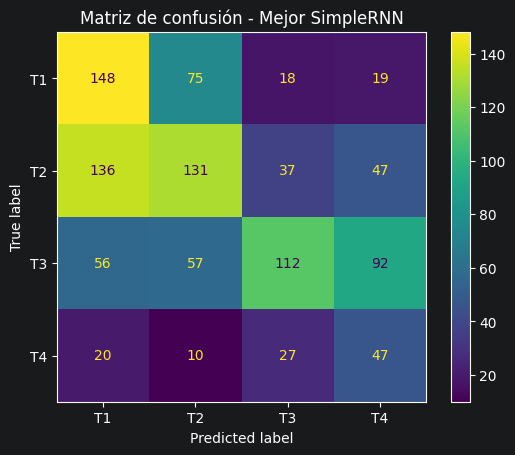

In [57]:
if best_y_true is not None:
    cm = confusion_matrix(best_y_true, best_y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=best_labels
    )

    disp.plot()
    plt.title("Matriz de confusión - Mejor SimpleRNN")
    plt.show()